In [47]:
import os
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as stats 
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import LabelEncoder
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import time
import shap
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import GroupKFold
from sklearn.impute import KNNImputer
from haversine import haversine
from sklearn.neighbors import BallTree
import xgboost
from xgboost import XGBRegressor  # ✅ This is the actual regressor class
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split # split  data into training and testing sets
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer # for scoring during cross validation
from sklearn.model_selection import GridSearchCV # cross validation
from sklearn.metrics import ConfusionMatrixDisplay # creates and draws a confusion matrix

In [37]:
print("Current working directory:", os.getcwd())
df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv")

print(list(df.columns))

# df = df[df["Grain.yield..tons.ha.1."] <= 100]

# df.to_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv", index=False)

Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soil_N', 'pr_irrigated', 'AEZ', '

/tmp/ipykernel_76520/755187446.py:2: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,69,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/finaldatasets/testdata/RFgdpadded12-7.csv")


In [38]:
#Format columns for producing a tree
df.columns = df.columns.str.replace(' ', '_')

In [39]:
# Replace blank or empty cells with np.nan
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

#make sure all columns have nan so xgboost can handle it
(df == ' ').sum().sum()

0

##### Generate plots to see if yield is normally distributed

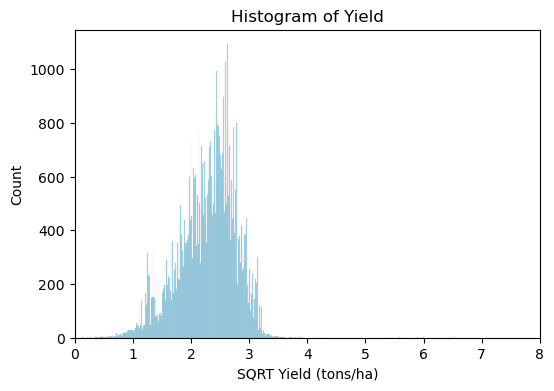

In [11]:
#Histogram of yield (yield values filtered to below 100 and square-rooted for better visualization)
y = np.sqrt(df["Grain.yield..tons.ha.1."].dropna())
y = y[y < 100]  # Filter out extreme values for better visualization

plt.figure(figsize=(6, 4))
sns.histplot(y, kde=False, bins=1000, color='skyblue')
plt.title("Histogram of Yield")
plt.xlabel("SQRT Yield (tons/ha)")
plt.xlim(0,8)
plt.grid(False)
plt.show()

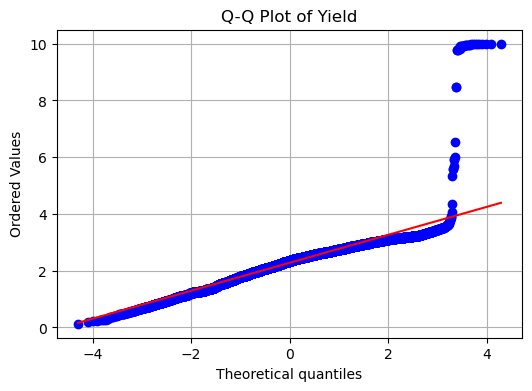

In [12]:
# Q-Q plot of yield to check normality

plt.figure(figsize=(6, 4))
stats.probplot(y, dist="norm", plot=plt)
plt.title("Q-Q Plot of Yield")
plt.grid(True)
plt.show()

In [10]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   78013 |          100   |      77619 |
| Location.source                                       | object  |   78013 |          100   |          9 |
| year                                                  | int64   |   78013 |          100   |         42 |
| Elevation                                             | float64 |   78013 |          100   |        202 |
| Data.ID                                               | object  |   78013 |          100   |         54 |
| end_date                                              | int64   |   78013 |          100   |         10 |
| start_date                                            | int64   |   78013 |          100   |          7 |
| Grain.yield..tons.ha.1.   

In [40]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude",

HIGH_CARDINALITY_COLS = [
    "Crop.variety", "Treatment.type", "Emissions..yes.no.",
    "N.type", "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use – Rodenticides (t)", "Agricultural_Use_–_Other_Pesticides_nes_(t)"
    "irr_end_date", "end_date"
]

COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# Drop each group of columns sequentially for clarity
df_no_location = df.drop(columns=[col for col in LOCATION_COLS if col in df.columns])
df_no_high_card = df_no_location.drop(columns=[col for col in HIGH_CARDINALITY_COLS if col in df_no_location.columns])
df_cleaned = df_no_high_card.drop(columns=[col for col in COLLINEAR_COLS if col in df_no_high_card.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped location columns:", [col for col in LOCATION_COLS if col in df.columns])
print("Dropped high-cardinality columns:", [col for col in HIGH_CARDINALITY_COLS if col in df.columns])
print("Dropped collinear columns:", [col for col in COLLINEAR_COLS if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 30 percent completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])

Original shape: (78013, 95)
Shape after dropping: (78013, 70)
Dropped location columns: ['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Location.source', 'Observation.period']
Dropped high-cardinality columns: ['Crop.variety', 'Treatment.type', 'Emissions..yes.no.', 'N.type', 'Irrigation..mm.', 'Harvesting.date.1', 'Pest.severity.score.......66', 'end_date']
Dropped collinear columns: ['harvest_month', 'harvest_date_clean', 'harvest_week', 'Planting.date', 'Planting_Month', 'Planting.date.1', 'Planting_Week']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Wheat.Type', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Pest.prescence....6

In [7]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Soil.type               50
Tillage.type            22
Treatment_Category      14
Wheat.Type               7
irrigation_applied       4
Treatment                2
Pest.prescence....64     2
dtype: int64

### Onehot encode and prepare data

In [41]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Add spatial coordinates
X["lon"] = df_cleaned["Conversion.for.longitude"]
X["lat"] = df_cleaned["Conversion.for.latitude"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,Conversion.for.latitude,Conversion.for.longitude,Mean.annual.precipitation..mm.,Sand,Silt,Clay,Soil.organic.carbon..g.C.kg.1.,Soil.pH,N.rate..kg.N.ha.1.,P.rate..kg.P.ha.1.,rainfed_start_date,rainfed_end_date,irr_start_date,irr_end_date,start_date,Soil_N,pr_irrigated,AEZ,Elevation,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,Irrigation.mm_clean,harvest_dayofyear,gdp,hdi,year,dryspells(5days),drydays(annualsum),Year_x,Agricultural_Use_–_Fungicides_and_Bactericides_(t),Agricultural_Use_–_Herbicides_(t),Agricultural_Use_–_Insecticides_(t),Agricultural_Use_–_Other_Pesticides_nes_(t),Agricultural_Use_–_Pesticides_(total)_(t),Agricultural_Use_–_Rodenticides_(t),Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha),lon,lat,Wheat.Type_Triticum aestivum,Wheat.Type_Triticum aestivum L.,Wheat.Type_Triticum aestivum),Wheat.Type_Triticum aestivumÂ L.,Wheat.Type_Triticum durum,Wheat.Type_Triticum durum Desf.,Wheat.Type_Triticum turgidum,Tillage.type_CT,Tillage.type_Conservation,Tillage.type_Conventional,Tillage.type_Deep ploughing,Tillage.type_Manual hoeing,Tillage.type_No tillage,Tillage.type_No-tillage,Tillage.type_Ploughing,Tillage.type_Plowing tillage,Tillage.type_RI,Tillage.type_Reduce-tillage,Tillage.type_Rotary,Tillage.type_Rotary tillage,Tillage.type_Tillage,Tillage.type_ZT,Tillage.type_cultivator,Tillage.type_cultivator and disk harrow,"Tillage.type_cultivator autumn 0,15 m",Tillage.type_harrow,Tillage.type_plough,"Tillage.type_plough autumn 0,2 m","Tillage.type_power harrow autumn 0,1 m",Treatment_Control,Treatment_Treatment,Soil.type_Alfisol,Soil.type_Black cambisol,Soil.type_Calcaric Cambisol,Soil.type_Calcaric cambisol,Soil.type_Calcic Cambisols,Soil.type_Calcic Xerosols,Soil.type_Cambisol,Soil.type_Chromic Vertisols,Soil.type_Clay,Soil.type_Clay (nitosols),Soil.type_Clay loam,Soil.type_Clay loam (gleysols),Soil.type_Clay loam (luvisol),Soil.type_Clay vertisol,Soil.type_Dystroferric Red Latosol (Oxisol),Soil.type_Eum-Orthrosols,Soil.type_Eutric vertisol,Soil.type_Heavy clay soil,"Soil.type_Hyposodic Vertisol (Calcaric, Chromic)",Soil.type_Light loam,Soil.type_Loam,Soil.type_Luvisol,Soil.type_Luvisol and vertisol,Soil.type_Luvisols,Soil.type_Nitisol,Soil.type_Nitosol,Soil.type_Oxisol (Latossolo Vermelho distrÃ³fico) with clayey texture,Soil.type_Paddy-soil,Soil.type_Podzoluvisol,Soil.type_Regosol,Soil.type_Sand,Soil.type_Sandy clay loam,Soil.type_Sandy limestone,Soil.type_Sandy loam,Soil.type_Sandy loam soil,Soil.type_Sandy-loam,Soil.type_Silt clay loam,Soil.type_Silt loam,Soil.type_Silt-clay,Soil.type_Silty clay,Soil.type_Silty loam,Soil.type_Stagnic Gleysol,Soil.type_Stagnic Luvisol,Soil.type_Trix clay loam,Soil.type_Vertisol,"Soil.type_clayey Latossolo Vermelho distrÃ³fico, Typic Haplustox",Soil.type_comingled Kalamazoo and Oshtemo,Soil.type_loam,Soil.type_sandy_clay_loam,Soil.type_sandy_loam,Pest.prescence....64_No,Pest.prescence....64_Yes,irrigation_applied_flooding,irrigation_applied_mm_provided,irrigation_applied_no,irrigation_applied_yes,Treatment_Category_Application Methods,Treatment_Category_Combined Organic-Inorganic,Treatment_Category_Control,Treatment_Category_Crop Residue & Plant-based,Treatment_Category_Enhanced Efficiency,Treatment_Category_Inorganic Nitrogen,Treatment_Category_Micronutrients & Secondary,Treatment_Category_Mineral Fertilizers,Treatment_Category_NPK Complex,Treatment_Category_Nitrogen Rate Treatments,Treatment_Category_Organic Animal-based,Treatment_Category_Other,Treatment_Category_Phosphorus & Potassium,Treatment_Category_Specialty Treatments
0,38.433333,-121.866667,480.0,32.0,38.333332,29.6,12.483334,6.933333,0.0,NaN,10.0,7.0,9.0,6.0,10.0,1.4,75.305054,27.0,21.0,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,NaN,NaN,52398.04,0.940856,2010.0,15.000123,298.00037,2010.0,21923.6,225586.43,63956.47,63351.7,374818.2,0.0,2.28,-1

RF with spacial and temporal blocking? 

In [42]:
#🌍 BLOCK 2: Spatial Grouping (Haversine Clustering)

coords = df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().values
coords_rad = np.deg2rad(coords)
tree = BallTree(coords_rad, metric='haversine')

radius_km = 100
radius = radius_km / 6371.0

groups, visited = [], np.zeros(len(coords), dtype=bool)
for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

df_cleaned.loc[
    df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().index,
    'spatial_group'
] = spatial_group_labels


In [43]:
#⏳ BLOCK 3–4: Temporal & Combined Group Labels
temporal_groups = df_cleaned['year'].astype(str).values

combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}" 
    for spatial, temporal in zip(df_cleaned['spatial_group'], temporal_groups)
])


In [ ]:
# 🌲 BLOCK 5: XGBoost Regressor + Random Search + GroupKFold
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=5)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",        # efficient & sparsity-aware
    missing=np.nan,            # critical for NaN handling
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [4, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_encoded, y, groups=combined_groups),
    verbose=1,
    n_jobs=-1
)

search.fit(X_encoded, y)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Final model running

In [ ]:
# Final fit on full data using best hyperparameters
best_model = search.best_estimator_

best_model.fit(
    X_encoded, y,
    eval_set=[(X_encoded, y)],
    eval_metric="mae",
    early_stopping_rounds=10,
    verbose=True
)

y_pred = best_model.predict(X_encoded)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.tight_layout()
plt.show()


#make shap plots
# Explain model predictions using SHAP
explainer = shap.Explainer(best_model)
shap_values = explainer(X_encoded)

# Summary plot
shap.summary_plot(shap_values, X_encoded, plot_type="bar")

# (Optional) full beeswarm for top features
shap.summary_plot(shap_values, X_encoded)